In [1]:
from scipy.stats import pearsonr
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
import concurrent.futures

In [2]:
expr_path = "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/processed/WMB-10Xv3-Isocortex-1-log2-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [3]:
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-modules.csv",
    index_col = "Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_green,kME_brown,kME_grey,kME_blue,kME_turquoise,kME_yellow,kME_red
ENSMUSG00000015090,ENSMUSG00000015090,green,green,0.653472,-0.032236,-0.115646,0.123502,0.069904,0.154395,-0.175664
ENSMUSG00000031425,ENSMUSG00000031425,green,green,0.921549,-0.047739,-0.106292,0.077948,0.088522,0.202247,-0.212231
ENSMUSG00000115529,ENSMUSG00000115529,green,green,0.283788,-0.010976,-0.029480,0.021220,0.017650,0.086082,-0.085927
ENSMUSG00000029819,ENSMUSG00000029819,brown,brown,-0.017231,0.547982,-0.066836,-0.008960,-0.004381,0.005224,-0.110663
ENSMUSG00000024610,ENSMUSG00000024610,grey,grey,0.007531,-0.025541,-0.034615,0.028825,0.155726,0.004847,-0.031323


In [4]:
merfish_panel_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/gene_panel.csv"
)
merfish_panel_df.head()

,gene_identifier,gene_symbol,transcript_identifier
0,ENSMUSG00000026778,Prkcq,ENSMUST00000028118
1,ENSMUSG00000026837,Col5a1,ENSMUST00000028280
2,ENSMUSG00000001985,Grik3,ENSMUST00000030676
3,ENSMUSG00000039323,Igfbp2,ENSMUST00000047328
4,ENSMUSG00000048387,Osr1,ENSMUST00000057021


In [5]:
# Getting all module names
all_modules = modules_df["color"].unique().tolist()

# No permutation

In [ ]:
tau_df = pd.DataFrame(columns=["module", "number of total genes", "number of common genes", "Pearson r",\
    "Whole module Tau", "Common module Tau"])

for select_module in set(all_modules) - {"grey"}:
    # ME for the whole module
    print("Current module: ", select_module)
    select_genes = modules_df[modules_df["module"] == select_module].index
    print("Number of genes in the module: ", select_genes.shape[0])
    common_genes = adata.var_names.intersection(select_genes)
    adata_subset = adata[:,common_genes].copy()
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    sc.pp.scale(adata_subset, max_value=10)
    sc.tl.pca(adata_subset, n_comps = 2, svd_solver="arpack")
    adata_subset.obs[select_module] = adata_subset.obsm['X_pca'][:,0]

    # ME for common genes with MERFISH
    merfish_genes = select_genes.intersection(merfish_panel_df['gene_identifier'])
    print("Number of module genes in the merfish panel: ", merfish_genes.shape[0])
    adata_common = adata[:,merfish_genes].copy()
    sc.pp.normalize_total(adata_common, target_sum=1e4)
    sc.pp.log1p(adata_common)
    sc.pp.scale(adata_common, max_value=10)
    sc.tl.pca(adata_common, n_comps = 2, svd_solver="arpack")
    adata_common.obs[select_module] = adata_common.obsm['X_pca'][:,0]

    # Getting Pearson correlation
    partial_corr = pearsonr(adata_subset.obsm['X_pca'][:,0], adata_common.obsm['X_pca'][:,0])

    # Tau score for whole module
    tau_full_df = adata_subset.obs[["class"]].copy()
    tau_full_df[select_module] = adata_subset.obsm['X_pca'][:,0]
    tau_full_df[select_module] = tau_full_df[select_module] - tau_full_df[select_module].min() + 1e-6
    avg_expression = tau_full_df.groupby('class')[select_module].mean()
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr
    tau_full = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)

    # Tau score for common module
    tau_common_df = adata_common.obs[["class"]].copy()
    tau_common_df[select_module] = adata_common.obsm['X_pca'][:,0]
    tau_common_df[select_module] = tau_common_df[select_module] - tau_common_df[select_module].min() + 1e-6
    avg_expression = tau_common_df.groupby('class')[select_module].mean()
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr
    tau_common = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)

    # Create a dictionary for this module's results
    new_row = {
        "module": select_module,
        "number of total genes": select_genes.shape[0],
        "number of common genes": merfish_genes.shape[0],
        "Pearson r": partial_corr[0],
        "Whole module Tau": tau_full,
        "Common module Tau": tau_common
    }
    
    # Append the new row to the dataframe using .loc
    tau_df.loc[len(tau_df)] = new_row

    del adata_subset, adata_common

# With permutation

In [6]:
# Function to compute Tau score from an AnnData object that has PCA computed
def compute_tau(adata_obj, module_obs_key):
    # Create a DataFrame with cell class and the module eigengene value
    tau_df = adata_obj.obs[['class']].copy()
    tau_df[module_obs_key] = adata_obj.obsm['X_pca'][:, 0]
    # Shift the values to be positive
    tau_df[module_obs_key] = tau_df[module_obs_key] - tau_df[module_obs_key].min() + 1e-6
    # Compute average expression per class
    avg_expression = tau_df.groupby('class')[module_obs_key].mean()
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr
    # Compute Tau: tau = sum(1 - normalized_expr)/(number_of_classes - 1)
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    return tau

In [7]:
# Define a function for one permutation iteration.
def permutation_tau(seed):
    # Set the random seed for reproducibility in this process.
    np.random.seed(seed)
    # Randomly sample genes without replacement
    random_genes = np.random.choice(all_genes, size=n_genes_in_module, replace=False)
    # Create a copy of adata for the selected genes
    adata_perm = adata[:, random_genes].copy()
    
    # Preprocess the subset (normalization, log transform, scaling, PCA)
    sc.pp.normalize_total(adata_perm, target_sum=1e4)
    sc.pp.log1p(adata_perm)
    sc.pp.scale(adata_perm, max_value=10)
    sc.tl.pca(adata_perm, n_comps=2, svd_solver="arpack")
    
    # Store the first principal component as the temporary module eigengene
    temp_key = "temp_module"
    adata_perm.obs[temp_key] = adata_perm.obsm['X_pca'][:, 0]
    
    # Compute and return the Tau score for this random gene set.
    return compute_tau(adata_perm, temp_key)

**One module**

Number of genes in module yellow: 181
Observed Tau score for module yellow: 0.823


/tmp/ipykernel_548701/1626331267.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/tmp/ipykernel_548701/1626331267.py:9: FutureWarning: Th

Permutation test p-value: 0.000


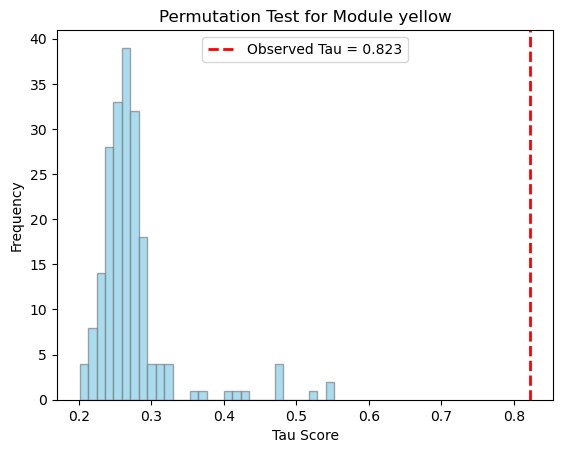

In [ ]:
# Parameters
n_permutations = 100  # number of random permutations
module_name = 'yellow'  # change this to the module you want to test

# Observed: Select the genes that belong to your module
select_genes = modules_df[modules_df["module"] == module_name].index
n_genes_in_module = select_genes.shape[0]
print(f"Number of genes in module {module_name}: {n_genes_in_module}")

# Compute the observed Tau score for the whole module
common_genes = adata.var_names.intersection(select_genes)
adata_subset = adata[:, common_genes].copy()

# Preprocess: normalization, log, scaling, PCA
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")

# Store the eigengene in obs with a key (here, we use the module name)
adata_subset.obs[module_name] = adata_subset.obsm['X_pca'][:, 0]
observed_tau = compute_tau(adata_subset, module_name)
print(f"Observed Tau score for module {module_name}: {observed_tau:.3f}")

# Get the list of all genes from the AnnData object
all_genes = adata.var_names

# Prepare random seeds for each permutation for reproducibility
seeds = np.random.randint(0, 1000000, size=n_permutations)

# Run the permutation iterations in parallel using ProcessPoolExecutor.
with concurrent.futures.ProcessPoolExecutor() as executor:
    tau_null = list(executor.map(permutation_tau, seeds))

tau_null = np.array(tau_null)

# Compute the p-value: proportion of permutations with Tau score >= observed_tau.
p_value = np.mean(tau_null >= observed_tau)
print(f"Permutation test p-value: {p_value:.3f}")

# Plot the null distribution with the observed Tau score
plt.hist(tau_null, bins=30, alpha=0.7, color='skyblue', edgecolor='gray')
plt.axvline(observed_tau, color='red', linestyle='dashed', linewidth=2,
            label=f'Observed Tau = {observed_tau:.3f}')
plt.xlabel("Tau Score")
plt.ylabel("Frequency")
plt.title(f"Permutation Test for Module {module_name}")
plt.legend()
plt.show()

**All modules: whole module**

In [ ]:
# Parameters
n_permutations = 1000  # number of random permutations

# Prepare a list to hold results for each module.
results = []

for module_name in set(all_modules) - {"grey"}:

    # Observed: Select the genes that belong to your module
    select_genes = modules_df[modules_df["module"] == module_name].index
    n_genes_in_module = select_genes.shape[0]
    print(f"Number of genes in module {module_name}: {n_genes_in_module}")

    # Compute the observed Tau score for the whole module
    common_genes = adata.var_names.intersection(select_genes)
    adata_subset = adata[:, common_genes].copy()

    # Preprocess: normalization, log, scaling, PCA
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    sc.pp.scale(adata_subset, max_value=10)
    sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")

    # Store the eigengene in obs with a key (here, we use the module name)
    adata_subset.obs[module_name] = adata_subset.obsm['X_pca'][:, 0]
    observed_tau = compute_tau(adata_subset, module_name)
    print(f"Observed Tau score for module {module_name}: {observed_tau:.3f}")

    # Get the list of all genes from the AnnData object
    all_genes = adata.var_names

    # Prepare random seeds for each permutation for reproducibility
    seeds = np.random.randint(0, 1000000, size=n_permutations)

    # Run the permutation iterations in parallel using ProcessPoolExecutor.
    with concurrent.futures.ProcessPoolExecutor() as executor:
        tau_null = list(executor.map(permutation_tau, seeds))

    tau_null = np.array(tau_null)

    # Compute the p-value: proportion of permutations with Tau score >= observed_tau.
    r = np.sum(tau_null >= observed_tau)
    p_value = (r + 1) / (n_permutations + 1)
    print(f"Permutation test p-value: {p_value:.5f}")

    results.append({
        "module": module_name,
        "n_total_genes": n_genes_in_module,
        "full_tau": observed_tau,
        "p_value": p_value
    })

results_df = pd.DataFrame(results)
results_df.to_csv("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-ME-sc-fullTau.csv")

Number of genes in module turquoise: 194


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Observed Tau score for module turquoise: 0.951


/tmp/ipykernel_706420/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()


**All modules: common genes**

In [10]:
# Parameters
n_permutations = 1000  # number of random permutations

# Prepare a list to hold results for each module.
results = []

for module_name in set(all_modules) - {"grey"}:

    # Observed: Select the genes that belong to your module
    select_genes = modules_df[modules_df["module"] == module_name].index
    n_genes_in_module = select_genes.shape[0]
    print(f"Number of genes in module {module_name}: {n_genes_in_module}")

    # Compute the observed Tau score for the whole module
    common_genes = select_genes.intersection(merfish_panel_df['gene_identifier'])
    print("Number of module genes in the merfish panel: ", common_genes.shape[0])
    adata_subset = adata[:, common_genes].copy()

    # Preprocess: normalization, log, scaling, PCA
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    sc.pp.scale(adata_subset, max_value=10)
    sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")

    # Store the eigengene in obs with a key (here, we use the module name)
    adata_subset.obs[module_name] = adata_subset.obsm['X_pca'][:, 0]
    observed_tau = compute_tau(adata_subset, module_name)
    print(f"Observed Tau score for module {module_name}: {observed_tau:.3f}")

    # Get the list of all genes from the AnnData object
    all_genes = adata.var_names

    # Prepare random seeds for each permutation for reproducibility
    seeds = np.random.randint(0, 1000000, size=n_permutations)

    # Run the permutation iterations in parallel using ProcessPoolExecutor.
    with concurrent.futures.ProcessPoolExecutor() as executor:
        tau_null = list(executor.map(permutation_tau, seeds))

    tau_null = np.array(tau_null)

    # Compute the p-value: proportion of permutations with Tau score >= observed_tau.
    r = np.sum(tau_null >= observed_tau)
    p_value = (r + 1) / (n_permutations + 1)
    print(f"Permutation test p-value: {p_value:.5f}")

    results.append({
        "module": module_name,
        "n_common_genes": common_genes.shape[0],
        "common_tau": observed_tau,
        "p_value": p_value
    })

results_df = pd.DataFrame(results)
results_df.to_csv("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-ME-sc-commonTau.csv")

Number of genes in module turquoise: 194
Number of module genes in the merfish panel:  11


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Observed Tau score for module turquoise: 0.927


/tmp/ipykernel_706420/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_706420/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_706420/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[

Permutation test p-value: 0.00000
Number of genes in module green: 119
Number of module genes in the merfish panel:  8


...

Permutation test p-value: 0.00000
Number of genes in module red: 93
Number of module genes in the merfish panel:  26


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Observed Tau score for module red: 0.611


/tmp/ipykernel_706420/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/tmp/ipykernel_706420/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sile

Permutation test p-value: 0.00000


**Final table**

In [4]:
full_df = pd.read_csv("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-ME-sc-fullTau.csv",\
    index_col = "Unnamed: 0")
common_df = pd.read_csv("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-ME-sc-commonTau.csv",\
    index_col = "Unnamed: 0")

In [8]:
merged_df = pd.merge(full_df, common_df, on="module", suffixes=("_full", "_common"))
merged_df.to_csv("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-ME-sc-mergedTau.csv")

In [9]:
merged_df.head()

,module,n_total_genes,full_tau,p_value_full,n_common_genes,common_tau,p_value_common
0,turquoise,194,0.951291,0.000,11,0.927318,0.0
1,green,119,0.882841,0.000,8,0.910657,0.0
2,blue,193,0.908571,0.000,18,0.858770,0.0
3,yellow,181,0.822702,0.000,30,0.846508,0.0
4,brown,192,0.538571,0.002,53,0.589211,0.0
